# Import Dataset

In [ ]:
!pip install sastrawi
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Download resource NLTK
nltk.download('punkt')
nltk.download('stopwords')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.2 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Load dataset
try:
    df = pd.read_csv('/content/KendaraanListrik.csv', delimiter=';', encoding='latin-1')
except UnicodeDecodeError:
    # If latin-1 fails, try another common encoding like cp1252
    df = pd.read_csv('/content/KendaraanListrik.csv', delimiter=';', encoding='cp1252')

# Tampilkan beberapa baris awal
df.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,quote_count,reply_count,retweet_count,tweet_url,user_id_str
0,"1,92E+18",Sun May 04 15:14:02 +0000 2025,0,1 alasan tidak memilih kendaraan listrik selai...,"1,92E+18",NaN,NaN,in,0.0,0.0,0.0,https://x.com/undefined/status/191904787469794...,802359780
1,"1,92E+18",Sun May 04 15:12:13 +0000 2025,2,@komunitaswevi @SelebtwitMobil @apanich80626 @...,"1,92E+18",NaN,komunitaswevi,in,0.0,1.0,0.0,https://x.com/undefined/status/191904741855476...,"1,12E+18"
2,"1,92E+18",Sun May 04 15:10:22 +0000 2025,0,@WulingMotorsID Sering Worry akan keterlambata...,"1,92E+18",NaN,WulingMotorsID,in,0.0,0.0,0.0,https://x.com/undefined/status/191904695169944...,1631503160
3,"1,92E+18",Sun May 04 15:09:36 +0000 2025,2,@komunitaswevi @SelebtwitMobil @apanich80626 @...,"1,92E+18",NaN,tayngasw,in,0.0,0.0,0.0,https://x.com/undefined/status/191904676186968...,"1,12E+18"
4,"1,92E+18",Sun May 04 15:08:26 +0000 2025,0,Harga sel baterai bisa mencapai 75% dr harga t...,"1,92E+18",NaN,NaN,in,0.0,0.0,0.0,https://x.com/undefined/status/191904646763505...,3307907731


# Preprocessing

# Case Folding


In [ ]:
df['case_folding'] = df['full_text'].astype(str).str.lower()

# Tampilkan hasil case folding
df[['full_text', 'case_folding']].head()

,full_text,case_folding
0,1 alasan tidak memilih kendaraan listrik selai...,1 alasan tidak memilih kendaraan listrik selai...
1,@komunitaswevi @SelebtwitMobil @apanich80626 @...,@komunitaswevi @selebtwitmobil @apanich80626 @...
2,@WulingMotorsID Sering Worry akan keterlambata...,@wulingmotorsid sering worry akan keterlambata...
3,@komunitaswevi @SelebtwitMobil @apanich80626 @...,@komunitaswevi @selebtwitmobil @apanich80626 @...
4,Harga sel baterai bisa mencapai 75% dr harga t...,harga sel baterai bisa mencapai 75% dr harga t...


# Punctuation Removal

In [ ]:
import re
def remove_punctuation(text):
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)  # hapus URL
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # hapus karakter non-alfanumerik kecuali spasi
    return text

df['punctuation_removed'] = df['case_folding'].apply(remove_punctuation)

# Tampilkan hasil punctuation removal
df[['case_folding', 'punctuation_removed']].head()


,case_folding,punctuation_removed
0,1 alasan tidak memilih kendaraan listrik selai...,1 alasan tidak memilih kendaraan listrik selai...
1,@komunitaswevi @selebtwitmobil @apanich80626 @...,komunitaswevi selebtwitmobil apanich80626 roda...
2,@wulingmotorsid sering worry akan keterlambata...,wulingmotorsid sering worry akan keterlambatan...
3,@komunitaswevi @selebtwitmobil @apanich80626 @...,komunitaswevi selebtwitmobil apanich80626 roda...
4,harga sel baterai bisa mencapai 75% dr harga t...,harga sel baterai bisa mencapai 75 dr harga to...


# Tokenize

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

df['tokenized'] = df['punctuation_removed'].apply(word_tokenize)

# Tampilkan hasil tokenisasi
df[['punctuation_removed', 'tokenized']].head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,punctuation_removed,tokenized
0,1 alasan tidak memilih kendaraan listrik selai...,"[1, alasan, tidak, memilih, kendaraan, listrik..."
1,komunitaswevi selebtwitmobil apanich80626 roda...,"[komunitaswevi, selebtwitmobil, apanich80626, ..."
2,wulingmotorsid sering worry akan keterlambatan...,"[wulingmotorsid, sering, worry, akan, keterlam..."
3,komunitaswevi selebtwitmobil apanich80626 roda...,"[komunitaswevi, selebtwitmobil, apanich80626, ..."
4,harga sel baterai bisa mencapai 75 dr harga to...,"[harga, sel, baterai, bisa, mencapai, 75, dr, ..."


# Stopword Removal

In [ ]:
# Install library Sastrawi
!pip install Sastrawi

In [ ]:
# Instal dan impor stopword Bahasa Indonesia dari Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Inisialisasi stopword list
factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

custom_stopwords = {
    'tp', 'gw', 'krn', 'ny', 'yg', 'dr', 'dgn', 'aja', 'klo', 'gk', 'ga', 'nggak',
    'trs', 'jg', 'udh', 'sm', 'sy', 'nya', 'loh', 'kok', 'deh', 'makanya',
    'lah', 'sih', 'dong', 'nih', 'tau', 'loe', 'lu', 'udah', 'blm', 'g','jdi', 'trus',
    'hbis', 'dia', 'org', 'spt', 'gak', 'ya', 'wkwkwk', 'wkwk'
}

default_stopwords = {
    'yang', 'dan', 'di', 'ke', 'dari', 'untuk', 'dengan', 'pada', 'adalah',
    'ini', 'itu', 'atau', 'juga', 'karena', 'sebagai', 'oleh', 'sudah', 'agar', 'dalam'
}

all_stopwords = default_stopwords.union(custom_stopwords)

df['stopwords_removed'] = df['tokenized'].apply(lambda tokens: [word for word in tokens if word not in all_stopwords])

# Tampilkan hasil setelah stopword removal
df[['tokenized', 'stopwords_removed']].head()

,tokenized,stopwords_removed
0,"[1, alasan, tidak, memilih, kendaraan, listrik...","[1, alasan, tidak, memilih, kendaraan, listrik..."
1,"[komunitaswevi, selebtwitmobil, apanich80626, ...","[komunitaswevi, selebtwitmobil, apanich80626, ..."
2,"[wulingmotorsid, sering, worry, akan, keterlam...","[wulingmotorsid, sering, worry, akan, keterlam..."
3,"[komunitaswevi, selebtwitmobil, apanich80626, ...","[komunitaswevi, selebtwitmobil, apanich80626, ..."
4,"[harga, sel, baterai, bisa, mencapai, 75, dr, ...","[harga, sel, baterai, bisa, mencapai, 75, harg..."


# Stemming

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Inisialisasi stemmer
stemmer = StemmerFactory().create_stemmer()

# Proses stemming, kecualikan 'an'
df['stemmed'] = df['stopwords_removed'].apply(lambda tokens: [word if word == 'an' else stemmer.stem(word) for word in tokens])

# Gabungkan token hasil stemming menjadi string
df['final_text'] = df['stemmed'].apply(lambda tokens: ' '.join(tokens))

# Tampilkan hasil: full_text (asli), final_text (hasil preprocessing)
df[['stopwords_removed', 'final_text']].head()

,stopwords_removed,final_text
0,"[1, alasan, tidak, memilih, kendaraan, listrik...",1 alas tidak pilih kendara listrik selain mura...
1,"[komunitaswevi, selebtwitmobil, apanich80626, ...",komunitaswevi selebtwitmobil apanich80626 roda...
2,"[wulingmotorsid, sering, worry, akan, keterlam...",wulingmotorsid sering worry akan lambat akibat...
3,"[komunitaswevi, selebtwitmobil, apanich80626, ...",komunitaswevi selebtwitmobil apanich80626 roda...
4,"[harga, sel, baterai, bisa, mencapai, 75, harg...",harga sel baterai bisa capai 75 harga total ke...


# Pelabelan

                                           full_text  \
0  1 alasan tidak memilih kendaraan listrik selai...   
1  @komunitaswevi @SelebtwitMobil @apanich80626 @...   
2  @WulingMotorsID Sering Worry akan keterlambata...   
3  @komunitaswevi @SelebtwitMobil @apanich80626 @...   
4  Harga sel baterai bisa mencapai 75% dr harga t...   
5  @komunitaswevi @SelebtwitMobil @apanich80626 @...   
6  @komunitaswevi @SelebtwitMobil @apanich80626 @...   
7  Kalau pengen memperluas ekosistem kendaraan li...   
8  @el_jastip Bran @gibran_tweet tolong jelaskan ...   
9  @el_jastip Jadi kendaraan listrik sebenernya t...   

                                          final_text    label  
0  1 alas tidak pilih kendara listrik selain mura...  negatif  
1  komunitaswevi selebtwitmobil apanich80626 roda...  negatif  
2  wulingmotorsid sering worry akan lambat akibat...  negatif  
3  komunitaswevi selebtwitmobil apanich80626 roda...  negatif  
4  harga sel baterai bisa capai 75 harga total ke...  negatif  

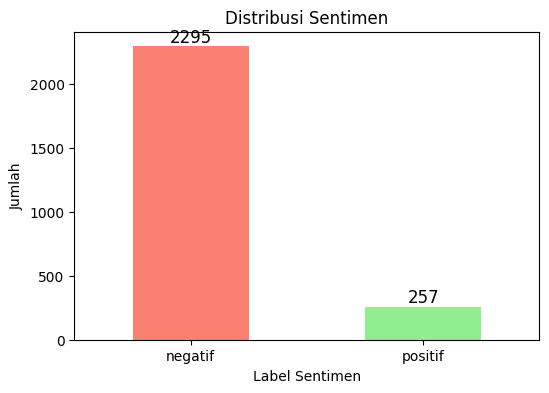

In [ ]:
import matplotlib.pyplot as plt

# Pelabelan sentimen sederhana berbasis keyword
positive_words = {'bagus', 'baik', 'mantap', 'hebat', 'cepat', 'murah', 'keren', 'suka', 'puas', 'nyaman'}
negative_words = {'buruk', 'jelek', 'lambat', 'mahal', 'tidak', 'benci', 'parah', 'mengecewakan', 'ribet', 'susah'}

def label_sentiment(text):
    text = text.lower()
    pos = sum(word in text for word in positive_words)
    neg = sum(word in text for word in negative_words)
    if pos > neg:
        return 'positif'
    else:
        return 'negatif'

# Terapkan pelabelan ke dataframe
df['label'] = df['final_text'].apply(label_sentiment)

# Tampilkan hasil pelabelan untuk 10 data pertama
print(df[['full_text', 'final_text', 'label']].head(10))

# Tampilkan total hasil positif dan negatif
print("Total sentimen:")
print(df['label'].value_counts())

label_counts = df['label'].value_counts()
plt.figure(figsize=(6,4))
ax = label_counts.plot(kind='bar', color=['salmon', 'lightgreen'])
plt.title('Distribusi Sentimen')
plt.xlabel('Label Sentimen')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)

# Tambahkan angka di atas setiap batang
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.show()

# SMOTE

Distribusi label setelah undersampling: Counter({'negatif': 650, 'positif': 650})


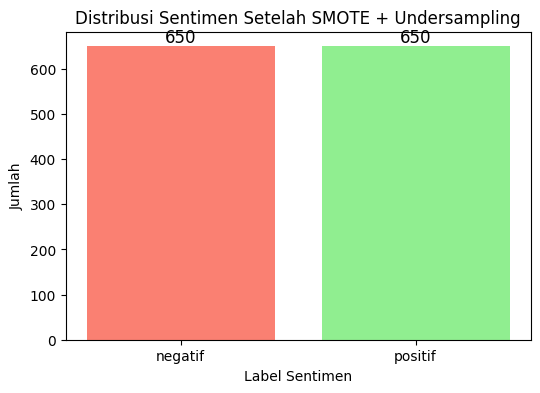

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['final_text'])
y = df['label']

# SMOTE untuk menyeimbangkan kelas
smote = SMOTE(random_state=42)
# Gunakan X dan y yang baru saja dibuat
X_resampled, y_resampled = smote.fit_resample(X, y)

# Gabungkan hasil SMOTE ke DataFrame sementara
df_resampled = pd.DataFrame(X_resampled.toarray())
df_resampled['label'] = y_resampled

# Undersampling agar total data sekitar 1000 (500 per kelas)
n_sample_per_class = 650
df_balanced = pd.concat([
    resample(df_resampled[df_resampled['label'] == label],
             replace=False,
             n_samples=n_sample_per_class,
             random_state=42)
    for label in df_resampled['label'].unique()
])

# Pisahkan kembali fitur dan label
X_final = df_balanced.drop('label', axis=1).values
y_final = df_balanced['label'].values

# Cek distribusi label setelah undersampling
print("Distribusi label setelah undersampling:", Counter(y_final))

# Visualisasi distribusi label setelah undersampling
label_counts_final = Counter(y_final)
plt.figure(figsize=(6,4))
bars = plt.bar(label_counts_final.keys(), label_counts_final.values(), color=['salmon', 'lightgreen'])
plt.title('Distribusi Sentimen Setelah SMOTE + Undersampling')
plt.xlabel('Label Sentimen')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)

# Tambahkan angka di atas setiap batang
for bar in bars:
    plt.annotate(str(int(bar.get_height())),
                 (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 ha='center', va='bottom', fontsize=12)

plt.show()

# TF-IDF

In [ ]:
# 2. Analisis 10 kata terbaik pada data hasil undersampling
tfidf_final_df = pd.DataFrame(X_final, columns=tfidf.get_feature_names_out())

# Frekuensi: jumlah dokumen yang mengandung kata
word_freq = (tfidf_final_df > 0).sum(axis=0)
top10_words = word_freq.sort_values(ascending=False).head(10).index.tolist()

result = []
for word in top10_words:
    freq = word_freq[word]
    tfidf_sum = tfidf_final_df[word].sum()
    tfidf_mean = tfidf_final_df[word].mean()
    result.append({'Kata': word, 'Frekuensi': freq, 'TF-IDF': tfidf_sum, 'TF-IDF Rata-rata': tfidf_mean})

result_df = pd.DataFrame(result)
print(result_df[['Kata', 'Frekuensi', 'TF-IDF', 'TF-IDF Rata-rata']])

        Kata  Frekuensi     TF-IDF  TF-IDF Rata-rata
0    listrik       1265  66.570095          0.051208
1      mobil       1084  70.366494          0.054128
2    kendara        440  37.115979          0.028551
3  indonesia        263  31.039015          0.023876
4      lebih        242  34.202769          0.026310
5        ada        211  20.138116          0.015491
6       bisa        210  21.221733          0.016324
7       tapi        203  20.722484          0.015940
8       buat        202  21.532496          0.016563
9       jadi        197  19.294204          0.014842


# Naive Bayes

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Inisialisasi dan latih model Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Prediksi pada data test
y_pred = nb.predict(X_test)

print(f"Jumlah data train : {X_train.shape[0]}")
print(f"Jumlah data test  : {X_test.shape[0]}")
print(f"Total data        : {X_train.shape[0] + X_test.shape[0]}")

# Evaluasi hasil
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

Jumlah data train : 1040
Jumlah data test  : 260
Total data        : 1300
Akurasi: 0.8153846153846154

Confusion Matrix:
 [[ 91  46]
 [  2 121]]

Classification Report:
               precision    recall  f1-score   support

     negatif       0.98      0.66      0.79       137
     positif       0.72      0.98      0.83       123

    accuracy                           0.82       260
   macro avg       0.85      0.82      0.81       260
weighted avg       0.86      0.82      0.81       260



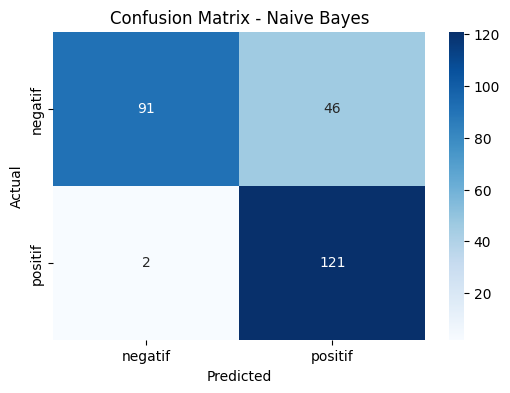

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = nb.classes_

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

# Decision Tree

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Inisialisasi dan latih model Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Prediksi pada data test
y_pred_dt = dt.predict(X_test)

print(f"Jumlah data train : {X_train.shape[0]}")
print(f"Jumlah data test  : {X_test.shape[0]}")
print(f"Total data        : {X_train.shape[0] + X_test.shape[0]}")

# Evaluasi hasil
print("Akurasi Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, zero_division=0))

Jumlah data train : 1040
Jumlah data test  : 260
Total data        : 1300
Akurasi Decision Tree: 0.9884615384615385

Confusion Matrix:
 [[135   2]
 [  1 122]]

Classification Report:
               precision    recall  f1-score   support

     negatif       0.99      0.99      0.99       137
     positif       0.98      0.99      0.99       123

    accuracy                           0.99       260
   macro avg       0.99      0.99      0.99       260
weighted avg       0.99      0.99      0.99       260



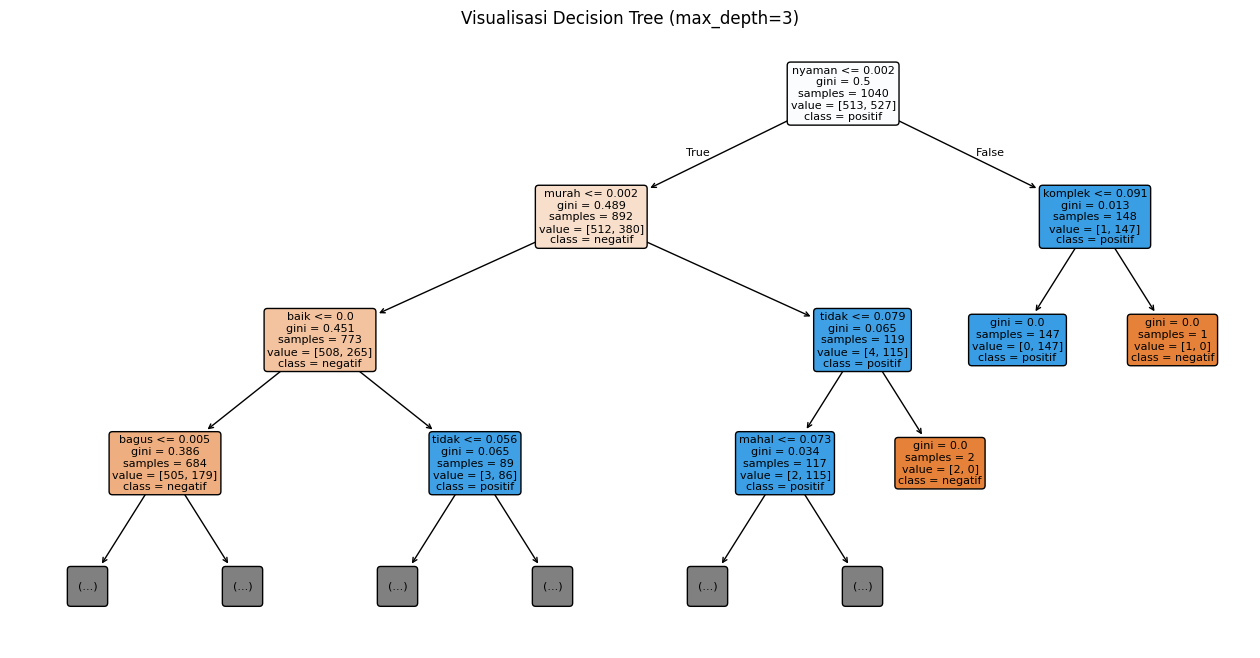

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))
plot_tree(
    dt,
    max_depth = 3,  # Batasi kedalaman agar visualisasi mudah dibaca
    feature_names=tfidf.get_feature_names_out(),
    class_names=dt.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Visualisasi Decision Tree (max_depth=3)")
plt.show()

# Evaluasi

# Perbandingan Naive Bayes dan Decision Tree

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Akurasi
acc_nb = accuracy_score(y_test, y_pred)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Akurasi Naive Bayes    : {acc_nb:.4f}")
print(f"Akurasi Decision Tree : {acc_dt:.4f}")

# Classification report
print("\nClassification Report Naive Bayes:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nClassification Report Decision Tree:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Akurasi Naive Bayes    : 0.8154
Akurasi Decision Tree : 0.9885

Classification Report Naive Bayes:
              precision    recall  f1-score   support

     negatif       0.98      0.66      0.79       137
     positif       0.72      0.98      0.83       123

    accuracy                           0.82       260
   macro avg       0.85      0.82      0.81       260
weighted avg       0.86      0.82      0.81       260


Classification Report Decision Tree:
              precision    recall  f1-score   support

     negatif       0.99      0.99      0.99       137
     positif       0.98      0.99      0.99       123

    accuracy                           0.99       260
   macro avg       0.99      0.99      0.99       260
weighted avg       0.99      0.99      0.99       260

